# 0f — noise floor

> *"30 shots changing nothing, then compute the standard deviation of shot time
> and mean flow. That number is the noise floor, the Phase 3 deadband, and the
> honest go/no-go on closed-loop control. Do not skip this to get to the fun
> part."* — CLAUDE.md

This notebook answers one question: **how repeatable is a shot on this machine
when nothing is deliberately changed?** Everything downstream — whether
closed-loop control is worth building at all — depends on the answer.

## Refreshing the data

`analysis/espressolog.db` is a snapshot, not the live database, and it is
gitignored. To take a fresh one:

```bash
ssh root@espressolog.lan 'sqlite3 /var/lib/espressolog/espressolog.db ".backup /tmp/snap.db"'
scp root@espressolog.lan:/tmp/snap.db analysis/espressolog.db
ssh root@espressolog.lan 'rm -f /tmp/snap.db'
```

Use `.backup` rather than copying the file — the server runs in WAL mode, so a
plain `cp` of the `.db` misses everything still sitting in the `-wal`.

In [1]:
import sqlite3
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

DB = "espressolog.db"          # relative to analysis/
INK, MUTED, ACCENT = "#1F2933", "#6B7280", "#2F6F9F"

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})

shots = pd.read_sql_query("SELECT * FROM v_shot", sqlite3.connect(DB))
print(f"{len(shots)} shots, {shots.started_at.min()[:10]} to {shots.started_at.max()[:10]}")

78 shots, 2026-08-27 to 2026-09-28


## Filtering, and why each filter is there

A noise floor is only meaningful over shots that were *trying* to be identical.
Five filters, each for a stated reason:

| Filter | Why |
|---|---|
| `yield_final_g >= 15` | below this it is a drip or a knock, not a shot |
| `excluded != 1` | rows already marked bad by hand |
| `bean_name == 'Moonwalker'` | different coffee extracts differently |
| `grind_dial == 7.9` and one `grind_epoch` | CLAUDE.md invariant 5 — a grind setting is meaningless across an epoch boundary |
| `detector_version == '0a.6'` | **the one that matters most.** Earlier detectors measured `total_s` by a different rule — 0a.4 recorded a cup lift as the stop. Pooling them inflates σ for no physical reason. |

Plus two shots dropped by hand: **25 and 26** are a single pull the detector
split in two (both stamped 2026-09-06 07:01, giving an impossible 6.11 g/s on
the first fragment). They have since been flagged `excluded` in the database as
well, so a fresh snapshot drops them one step earlier in the funnel; the
explicit `DROP_IDS` is kept as a belt-and-braces guard.

In [2]:
DROP_IDS = [25, 26]   # one pull the detector split into two rows

steps = [
    ("all shots",                shots),
    ("yield >= 15 g",            lambda d: d[d.yield_final_g >= 15]),
    ("not excluded",             lambda d: d[d.excluded != 1]),
    ("bean = Moonwalker",        lambda d: d[d.bean_name == "Moonwalker"]),
    ("grind 7.9",                lambda d: d[d.grind_dial == 7.9]),
    ("detector 0a.6",            lambda d: d[d.detector_version == "0a.6"]),
    ("drop split shot 25/26",    lambda d: d[~d.id.isin(DROP_IDS)]),
]
cur, funnel = shots, []
for name, f in steps:
    cur = f(cur) if callable(f) else cur
    funnel.append({"step": name, "n": len(cur)})
clean = cur
display(pd.DataFrame(funnel).set_index("step"))
assert clean.grind_epoch_id.nunique() == 1, "multiple grind epochs — invariant 5"
print(f"clean set: n={len(clean)}, single grind epoch {clean.grind_epoch_id.iloc[0]}")

,n
step,
all shots,78
yield >= 15 g,64
not excluded,58
bean = Moonwalker,56
grind 7.9,55
detector 0a.6,48
drop split shot 25/26,46


clean set: n=46, single grind epoch 1.0


## The number

In [3]:
def spread(s):
    s = s.dropna()
    med = s.median()
    return pd.Series({
        "mean": s.mean(), "sd": s.std(), "cv %": 100 * s.std() / s.mean(),
        "median": med, "MAD": (s - med).abs().median(), "n": len(s),
    })

METRICS = ["total_s", "mean_flow_gps", "yield_final_g", "dose_ground_g"]
summary = pd.DataFrame({m: spread(clean[m]) for m in METRICS}).T
display(summary.round(3))

sd_t = clean.total_s.std()
sd_f = clean.mean_flow_gps.std()
print(f"\nNOISE FLOOR  shot time  sigma = {sd_t:.2f} s  ({100*sd_t/clean.total_s.mean():.1f} %)")
print(f"NOISE FLOOR  mean flow  sigma = {sd_f:.3f} g/s ({100*sd_f/clean.mean_flow_gps.mean():.1f} %)")

,mean,sd,cv %,median,MAD,n
total_s,24.068,3.429,14.248,23.910,2.415,46.0
mean_flow_gps,1.747,0.213,12.190,1.743,0.119,46.0
yield_final_g,37.585,2.230,5.934,37.645,1.005,46.0
dose_ground_g,18.113,0.448,2.474,18.106,0.005,46.0



NOISE FLOOR  shot time  sigma = 3.43 s  (14.2 %)
NOISE FLOOR  mean flow  sigma = 0.213 g/s (12.2 %)


Parametric and robust estimates agree — `MAD x 1.4826` reproduces σ closely for
both metrics — so the spread is a property of the distribution, not one outlier
dragging it. (One shot does sit high at ~2.6 g/s; the robust estimate is
deliberately insensitive to it.)

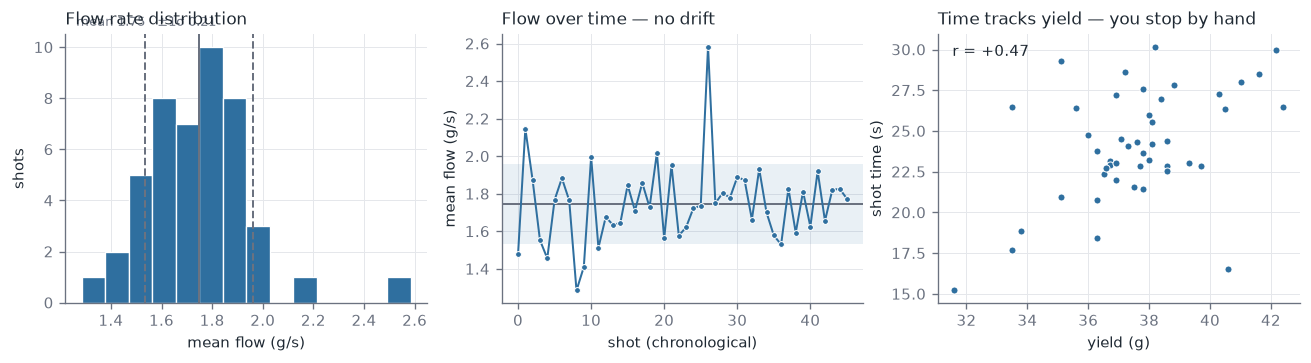

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))

ax = axes[0]
ax.hist(clean.mean_flow_gps, bins=14, color=ACCENT, edgecolor="white", linewidth=0.8)
m, s = clean.mean_flow_gps.mean(), clean.mean_flow_gps.std()
for x, ls in ((m, "-"), (m - s, "--"), (m + s, "--")):
    ax.axvline(x, color=MUTED, linewidth=1.2, linestyle=ls)
ax.annotate(f"mean {m:.2f}   ±1σ {s:.2f}", xy=(0.03, 1.02), xycoords="axes fraction",
            color=MUTED, fontsize=8, va="bottom")
ax.set_xlabel("mean flow (g/s)"); ax.set_ylabel("shots")
ax.set_title("Flow rate distribution", loc="left", color=INK, fontsize=10)

ax = axes[1]
d = clean.sort_values("started_at").reset_index(drop=True)
ax.axhspan(m - s, m + s, color=ACCENT, alpha=0.10, linewidth=0)
ax.axhline(m, color=MUTED, linewidth=1.2)
ax.plot(d.index, d.mean_flow_gps, marker="o", markersize=3.5, linewidth=1.2,
        color=ACCENT, markeredgecolor="white", markeredgewidth=0.6)
ax.set_xlabel("shot (chronological)"); ax.set_ylabel("mean flow (g/s)")
ax.set_title("Flow over time — no drift", loc="left", color=INK, fontsize=10)

ax = axes[2]
ax.scatter(clean.yield_final_g, clean.total_s, s=18, color=ACCENT,
           edgecolor="white", linewidth=0.6)
r = clean[["yield_final_g", "total_s"]].corr().iloc[0, 1]
ax.annotate(f"r = {r:+.2f}", xy=(0.04, 0.92), xycoords="axes fraction",
            color=INK, fontsize=9)
ax.set_xlabel("yield (g)"); ax.set_ylabel("shot time (s)")
ax.set_title("Time tracks yield — you stop by hand", loc="left", color=INK, fontsize=10)

fig.tight_layout()

The middle panel is the one to check first: **no drift**. If flow were trending
across five weeks, the spread would be a slow change (burr wear, a dosing shift)
rather than shot-to-shot noise, and pooling the shots would be invalid.

The right panel explains part of the time spread. You stop the shot by hand when
the scale reads your target, so `total_s` inherits the variance of *where you
stopped*. `mean_flow_gps` is the cleaner repeatability metric because it is a
rate, independent of the stop point.

## Is bean age a confound?

The clean set spans 16 to 39 days off roast, a wide range for a fixed recipe.
If extraction drifted with age, pooling would be illegitimate.

In [5]:
age = clean.dropna(subset=["days_off_roast", "mean_flow_gps"])
r_age = age[["days_off_roast", "mean_flow_gps"]].corr().iloc[0, 1]
print(f"corr(days_off_roast, mean_flow) = {r_age:+.3f}  (n={len(age)})")
print(f"days off roast: {int(age.days_off_roast.min())} to {int(age.days_off_roast.max())}\n")

bands = pd.DataFrame({
    f"{lo}-{hi} days": spread(clean[clean.days_off_roast.between(lo, hi)].mean_flow_gps)
    for lo, hi in [(16, 20), (27, 39)]
}).T
display(bands.round(3))

corr(days_off_roast, mean_flow) = +0.127  (n=46)
days off roast: 16 to 39



,mean,sd,cv %,median,MAD,n
16-20 days,1.692,0.273,16.137,1.765,0.231,11.0
27-39 days,1.764,0.192,10.875,1.736,0.102,35.0


Correlation is negligible and the two age bands give near-identical spreads, so
**bean age is not driving the result** and pooling across it is legitimate.

## Conclusion

**The noise floor is ~12 % on flow rate and ~14 % on shot time.**

What that means for Phase 3: any closed-loop controller that tries to resolve
differences smaller than this is chasing noise. That is a demanding floor, and it
is the honest go/no-go CLAUDE.md asked for.

Two caveats that matter before anyone reads this as a verdict on the machine:

1. **This is not machine noise.** It bundles grind, distribution, tamp and puck
   behaviour together with the hardware. A controller can only fight the part it
   can observe and actuate, so the achievable improvement is some fraction of
   this number — not all of it.
2. **`total_s` is still partly definitional.** It measures first-drip to plateau,
   not pump-on to pump-off. Milestone 0b (decoded 2026-09-28) fixes exactly this:
   the machine's display carries its own shot timer in tenths of a second. Logging
   it would give a cleaner shot-time series and show how much of that 3.4 s is
   real versus an artefact of where the detector decides a shot ended.

**Re-run this notebook once the display timer is logged.** The flow figure should
stand; the time figure may well shrink.